In [ ]:
# Setup and Imports
!pip install opencv-python scikit-image scikit-learn

import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from skimage.feature import graycomatrix, graycoprops, local_binary_pattern
from sklearn.decomposition import PCA

Saving photo-1773489425384-7fd20c7729dd.avif to photo-1773489425384-7fd20c7729dd.avif


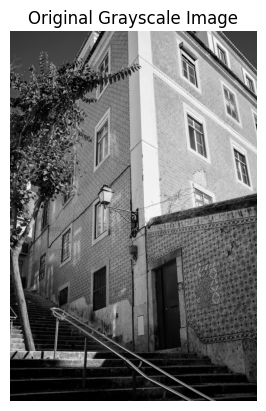

In [ ]:
# Image Upload and Grayscale Conversion
# ==========================
# Upload Image
# ==========================
uploaded = files.upload()
image_path = list(uploaded.keys())[0]

image = cv2.imread(image_path)
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

plt.imshow(gray, cmap='gray')
plt.title("Original Grayscale Image")
plt.axis('off')
plt.show()

In [ ]:
# GLCM Feature Extraction
# ==========================
# GLCM Features
# ==========================
glcm = graycomatrix(
    gray,
    distances=[1],
    angles=[0],
    levels=256,
    symmetric=True,
    normed=True
)

contrast = graycoprops(glcm, 'contrast')[0,0]
energy = graycoprops(glcm, 'energy')[0,0]
homogeneity = graycoprops(glcm, 'homogeneity')[0,0]
correlation = graycoprops(glcm, 'correlation')[0,0]

print("GLCM Features:")
print("Contrast:", contrast)
print("Energy:", energy)
print("Homogeneity:", homogeneity)
print("Correlation:", correlation)

GLCM Features:
Contrast: 481.5803460084325
Energy: 0.027120100563593416
Homogeneity: 0.20860555431420857
Correlation: 0.9482137676985225


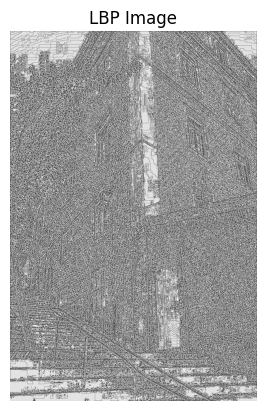

In [ ]:
# Local Binary Pattern (LBP) Calculation
# ==========================
# LBP (Local Binary Pattern)
# ==========================
radius = 1
n_points = 8 * radius

lbp = local_binary_pattern(
    gray,
    n_points,
    radius,
    method='uniform'
)

plt.imshow(lbp, cmap='gray')
plt.title("LBP Image")
plt.axis('off')
plt.show()

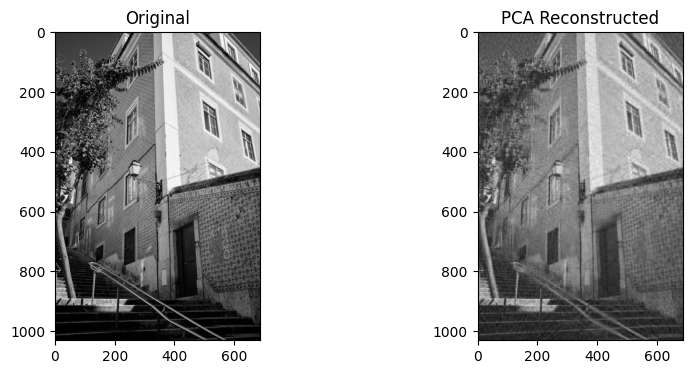

In [ ]:
# PCA (Principal Component Analysis) for Image Reconstruction
# ==========================
# PCA
# ==========================
reshaped = gray.reshape(-1, gray.shape[1])

pca = PCA(n_components=50)

pca_result = pca.fit_transform(reshaped)

reconstructed = pca.inverse_transform(pca_result)

reconstructed = reconstructed.reshape(gray.shape)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(gray, cmap='gray')
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(reconstructed, cmap='gray')
plt.title("PCA Reconstructed")

plt.show()